# PCG five-fold training

This notebook evaluates the PCG model using all five saved folds.

It trains five models. Each model trains on four folds and validates on the remaining fold. Every development patient is therefore used for validation once. At the end, the five models can score the community test set and their five probabilities are averaged for each patient.

Running all cells trains the five models, evaluates their averaged probability on the community test set, and displays the comparison with the original PCG model.

**Current decision:** keep the original PCG model as the baseline. These five-model results remain saved for reference. See the observations and conclusion below.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


def find_project_root():
    for candidate in (Path.cwd(), Path.cwd().parent):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.five_fold_validation import (
    evaluate_five_model_ensemble_on_test,
    inspect_five_fold_inputs,
    train_five_fold_models,
)

MODALITY = "pcg"
SEED = 42
BATCH_SIZE = 16
MAX_EPOCHS = 50
PATIENCE = 10

MODEL_DIR = PROJECT_ROOT / "models" / "five_fold_cross_validation" / f"{MODALITY}_seed{SEED}"
RESULT_DIR = PROJECT_ROOT / "analysis_outputs" / "five_fold_cross_validation" / f"{MODALITY}_seed{SEED}"

print(f"Project: {PROJECT_ROOT}")

Project: E:\Deep Learning\CardioFusion


## What the five folds do

The development set has 500 patients split into five fixed groups of 100. One run uses 400 patients for training and the other 100 for validation. This is repeated until every fold has been the validation fold once.

The validation fold serves two purposes: it chooses when that run should stop training, and it measures that run's result. This may make the reported development result slightly optimistic. It is still a clearer and more complete check than reporting only one validation fold.

After all five runs, the 500 validation predictions are joined. This gives one prediction for every development patient from a model that did not train on that patient. We use these predictions to choose the classification cutoffs. The community test labels are not used to choose a cutoff.

In [2]:
# This reads development metadata and one PCG tensor only.
# It does not load the community test set.
input_checks = inspect_five_fold_inputs(PROJECT_ROOT, modality=MODALITY)
display(input_checks)

development_metadata = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "patient_4ch" / "development" / "processed_metadata.csv",
    dtype={"Patient_ID": str},
)
fold_overview = development_metadata.groupby("Fold").agg(
    patients=("Patient_ID", "size"),
    hfref_patients=("Label", "sum"),
)
fold_overview["non_hfref_patients"] = fold_overview["patients"] - fold_overview["hfref_patients"]
display(fold_overview)

,modality,patients,hfref_patients,fold_sizes,input_shape,model_output_shape,training_crop_seconds
0,PCG,500,60,"{0: 100, 1: 100, 2: 100, 3: 100, 4: 100}","(4, 120000)","(1, 1)",15.0


,patients,hfref_patients,non_hfref_patients
Fold,,,
0,100,12,88
1,100,12,88
2,100,12,88
3,100,12,88
4,100,12,88


## Settings kept from notebook 3.1

The model design and main settings match the original notebook. The exact loss calculation differs; PCG also uses a different random sequence for choosing training crops. These runs therefore do not isolate the effect of using five folds.

- Input: a random 15-second PCG crop during training and the full 30 seconds during validation.
- Four sites remain together in the order APEX, LLSB, LUSB, RUSB.
- Model feature size: 128; dropout: 0.5.
- Focal loss is used for the class imbalance.
- Learning rate: 0.001; weight decay: 0.001; batch size: 16.
- Training stops early using validation AUROC, with at most 50 epochs and patience of 10 epochs.

No augmentation is added here beyond the random PCG crop already used by the original PCG notebook. Keeping the settings close to the old notebook makes the comparison easier to understand.

## Train five models

The next cell trains all five runs. Model files are saved outside Git because they are large. Tables with the development predictions and results are saved in `analysis_outputs/five_fold_cross_validation`.

Running the notebook again replaces the earlier five-fold model files and result tables with the new run.

In [3]:
train_five_fold_models(
    PROJECT_ROOT,
    modality=MODALITY,
    seed=SEED,
    batch_size=BATCH_SIZE,
    learning_rate=0.001,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
)
print(f"Finished. Results saved in: {RESULT_DIR}")

PCG fold 0 | epoch 1 | train loss 0.0787 | validation AUROC 0.5322 | average precision 0.1793


PCG fold 0 | epoch 2 | train loss 0.0515 | validation AUROC 0.6326 | average precision 0.2355


PCG fold 0 | epoch 3 | train loss 0.0365 | validation AUROC 0.5824 | average precision 0.2274


PCG fold 0 | epoch 4 | train loss 0.0371 | validation AUROC 0.6477 | average precision 0.2385


PCG fold 0 | epoch 5 | train loss 0.0345 | validation AUROC 0.6203 | average precision 0.2291


...

PCG fold 4 | epoch 43 | train loss 0.0227 | validation AUROC 0.8097 | average precision 0.4858


PCG fold 4 | epoch 44 | train loss 0.0260 | validation AUROC 0.7936 | average precision 0.4737


PCG fold 4 | epoch 45 | train loss 0.0223 | validation AUROC 0.8030 | average precision 0.4693


PCG fold 4 | epoch 46 | train loss 0.0210 | validation AUROC 0.8068 | average precision 0.4629


Finished. Results saved in: E:\Deep Learning\CardioFusion\analysis_outputs\five_fold_cross_validation\pcg_seed42


## Development results

These cells work after training finishes. Until then, they show a short message instead of failing.

AUROC and AUPRC judge how well patients are ranked across all possible cutoffs. Recall is the share of HFrEF patients found. Specificity is the share of non-HFrEF patients correctly rejected. Precision is the share of positive predictions that really are HFrEF. Balanced accuracy gives equal importance to recall and specificity.

In [4]:
development_summary_path = RESULT_DIR / "development_summary.csv"
fold_results_path = RESULT_DIR / "fold_results.csv"
oof_predictions_path = RESULT_DIR / "development_oof_predictions.csv"

if development_summary_path.is_file():
    development_summary = pd.read_csv(development_summary_path)
    fold_results = pd.read_csv(fold_results_path)
    oof_predictions = pd.read_csv(oof_predictions_path, dtype={"Patient_ID": str})

    columns = [
        "cutoff_rule", "development_cutoff", "auroc", "auprc", "recall",
        "specificity", "balanced_accuracy", "precision", "f1", "brier",
        "calibration_error", "tn", "fp", "fn", "tp",
    ]
    display(development_summary[columns].round(4))
    display(fold_results[columns[:1] + ["validation_fold"] + columns[1:9]].round(4))

    assert len(oof_predictions) == 500
    assert oof_predictions["Patient_ID"].is_unique
    assert set(oof_predictions["Fold"]) == set(range(5))
    print("Confirmed: every development patient has exactly one out-of-fold prediction.")
else:
    print("Development results are not available because training has not been run.")

,cutoff_rule,development_cutoff,auroc,auprc,recall,specificity,balanced_accuracy,precision,f1,brier,calibration_error,tn,fp,fn,tp
0,maximum_development_f1,0.5687,0.7573,0.3249,0.3833,0.9136,0.6485,0.3770,0.3802,0.2369,0.3738,402,38,37,23
1,target_90pct_development_specificity,0.5577,0.7573,0.3249,0.3833,0.9000,0.6417,0.3433,0.3622,0.2369,0.3738,396,44,37,23


,cutoff_rule,validation_fold,development_cutoff,auroc,auprc,recall,specificity,balanced_accuracy,precision,f1
0,maximum_development_f1,0,0.5687,0.7775,0.4090,0.7500,0.7614,0.7557,0.3000,0.4286
1,maximum_development_f1,1,0.5687,0.8845,0.5557,0.5833,0.9545,0.7689,0.6364,0.6087
2,maximum_development_f1,2,0.5687,0.7008,0.4232,0.0000,1.0000,0.5000,0.0000,0.0000
3,maximum_development_f1,3,0.5687,0.6856,0.2211,0.0833,0.9773,0.5303,0.3333,0.1333
4,maximum_development_f1,4,0.5687,0.8352,0.4590,0.5000,0.8750,0.6875,0.3529,0.4138
5,target_90pct_development_specificity,0,0.5577,0.7775,0.4090,0.7500,0.7386,0.7443,0.2812,0.4091
6,target_90pct_development_specificity,1,0.5577,0.8845,0.5557,0.5833,0.9432,0.7633,0.5833,0.5833
7,target_90pct_development_specificity,2,0.5577,0.7008,0.4232,0.0000,1.0000,0.5000,0.0000,0.0000
8,target_90pct_development_specificity,3,0.5577,0.6856,0.2211,0.0833,0.9545,0.5189,0.2000,0.1176
9,target_90pct_development_specificity,4,0.5577,0.8352,0.4590,0.5000,0.8636,0.6818,0.3333,0.4000


Confirmed: every development patient has exactly one out-of-fold prediction.


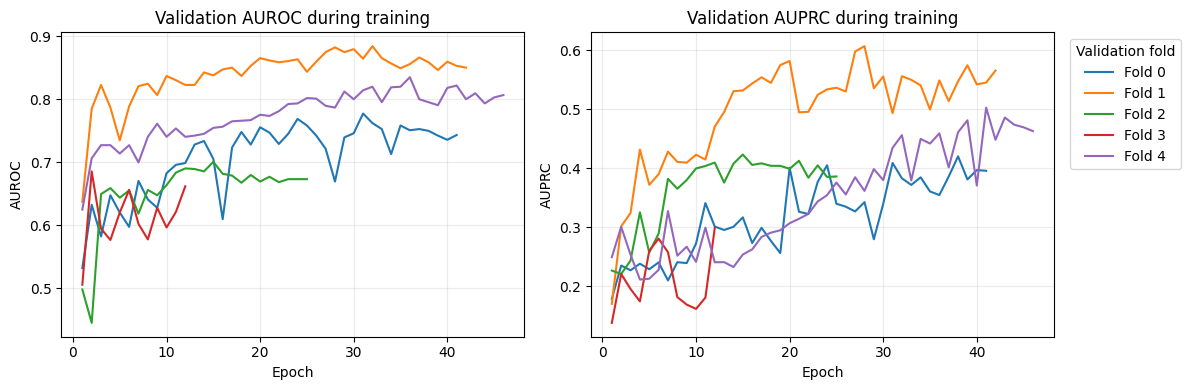

In [5]:
history_paths = [MODEL_DIR / f"fold_{fold}" / "history.csv" for fold in range(5)]
if all(path.is_file() for path in history_paths):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
    for fold, path in enumerate(history_paths):
        history = pd.read_csv(path)
        axes[0].plot(history["epoch"], history["val_auroc"], label=f"Fold {fold}")
        axes[1].plot(history["epoch"], history["val_auprc"], label=f"Fold {fold}")
    axes[0].set(title="Validation AUROC during training", xlabel="Epoch", ylabel="AUROC")
    axes[1].set(title="Validation AUPRC during training", xlabel="Epoch", ylabel="AUPRC")
    for axis in axes:
        axis.grid(alpha=0.25)
    axes[1].legend(title="Validation fold", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Training curves will appear after all five models have been trained.")

## Community Test Set

Community-test patients are kept out of training. Evaluation measures performance on patients the models did not train on; it does not update model weights. Training settings, stopping points, and cutoffs are chosen using development data. Earlier notebooks have also reported results on this test set. If we use those test results to choose a model or plan changes, the test set also influences our decisions, even though it never updates the weights.

The next cell makes one probability from each of the five models for every community-test patient, averages those five values, and applies the cutoffs chosen from development predictions. It then compares the ensemble with the original single model.

Because the community test set has only five HFrEF patients, one changed HFrEF decision changes recall by 20 percentage points. The result should therefore be read carefully.

There is also a cutoff limitation: each development patient has a probability from one held-out model, while each test patient has an average from five models. Averaging can change the spread of the probabilities. For this reason, AUROC and AUPRC are the clearest comparison, and cutoff-based results are reported with this limitation.

In [6]:
evaluate_five_model_ensemble_on_test(
    PROJECT_ROOT,
    modality=MODALITY,
    seed=SEED,
    batch_size=BATCH_SIZE,
)
print(f"Community test results saved in: {RESULT_DIR}")

Community test results saved in: E:\Deep Learning\CardioFusion\analysis_outputs\five_fold_cross_validation\pcg_seed42


In [7]:
test_results_path = RESULT_DIR / "community_test_results.csv"
if test_results_path.is_file():
    test_results = pd.read_csv(test_results_path)
    test_columns = [
        "model", "cutoff_rule", "development_cutoff", "test_auroc", "test_auprc",
        "test_recall", "test_specificity", "test_balanced_accuracy",
        "test_precision", "test_f1", "test_brier", "test_calibration_error",
        "test_tn", "test_fp", "test_fn", "test_tp", "result_source",
    ]
    display(test_results[test_columns].round(4))

    ensemble_rows = test_results[test_results["model"].str.startswith("Five-model")]
    old_row = test_results[~test_results["model"].str.startswith("Five-model")].iloc[0]
    primary_ensemble = ensemble_rows[
        ensemble_rows["cutoff_rule"].eq("maximum_development_f1")
    ].iloc[0]
    print("Plain-language comparison using the cutoff fixed by development F1:")
    print(f"- Old model AUROC: {old_row.test_auroc:.3f}; five-model average AUROC: {primary_ensemble.test_auroc:.3f}.")
    print(f"- Old model AUPRC: {old_row.test_auprc:.3f}; five-model average AUPRC: {primary_ensemble.test_auprc:.3f}.")
    print(f"- Old model recall: {old_row.test_recall:.3f}; five-model average recall: {primary_ensemble.test_recall:.3f}.")
    print(f"- Old model specificity: {old_row.test_specificity:.3f}; five-model average specificity: {primary_ensemble.test_specificity:.3f}.")
else:
    print("Community test results have not been created.")

,model,cutoff_rule,development_cutoff,test_auroc,test_auprc,test_recall,test_specificity,test_balanced_accuracy,test_precision,test_f1,test_brier,test_calibration_error,test_tn,test_fp,test_fn,test_tp,result_source
0,Five-model PCG ensemble,maximum_development_f1,0.5687,0.6470,0.2689,0.2,0.9217,0.5609,0.1000,0.1333,0.2504,0.4653,106,9,4,1,five_model_probability_average
1,Five-model PCG ensemble,target_90pct_development_specificity,0.5577,0.6470,0.2689,0.4,0.8957,0.6478,0.1429,0.2105,0.2504,0.4653,103,12,3,2,five_model_probability_average
2,Original notebook 3.1 single model,original_saved_cutoff,0.5028,0.8748,0.1623,1.0,0.6261,0.8130,0.1042,0.1887,NaN,NaN,72,43,0,5,saved_notebook_output_checkpoint_unavailable


Plain-language comparison using the cutoff fixed by development F1:
- Old model AUROC: 0.875; five-model average AUROC: 0.647.
- Old model AUPRC: 0.162; five-model average AUPRC: 0.269.
- Old model recall: 1.000; five-model average recall: 0.200.
- Old model specificity: 0.626; five-model average specificity: 0.922.


### Note about the old PCG comparison

The old PCG model file is not present in this copy of the project. If it is still unavailable when the test cell runs, the comparison row uses the results already saved inside notebook 3.1. That row is clearly marked as a saved notebook result. It cannot provide new patient-level predictions, Brier score, or calibration error unless the old model file is restored.

## Test classification reports and confusion matrices

The reports show the results for both five-model cutoffs and the original PCG model. The confusion matrices use rows for the true class and columns for the predicted class.


Five-model PCG ensemble | maximum_development_f1 | cutoff 0.5687
              precision    recall  f1-score   support

   Non-HFrEF     0.9636    0.9217    0.9422       115
       HFrEF     0.1000    0.2000    0.1333         5

    accuracy                         0.8917       120
   macro avg     0.5318    0.5609    0.5378       120
weighted avg     0.9277    0.8917    0.9085       120



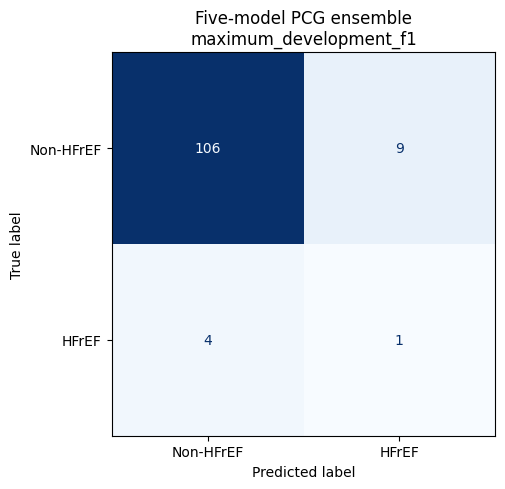


Five-model PCG ensemble | target_90pct_development_specificity | cutoff 0.5577
              precision    recall  f1-score   support

   Non-HFrEF     0.9717    0.8957    0.9321       115
       HFrEF     0.1429    0.4000    0.2105         5

    accuracy                         0.8750       120
   macro avg     0.5573    0.6478    0.5713       120
weighted avg     0.9372    0.8750    0.9021       120



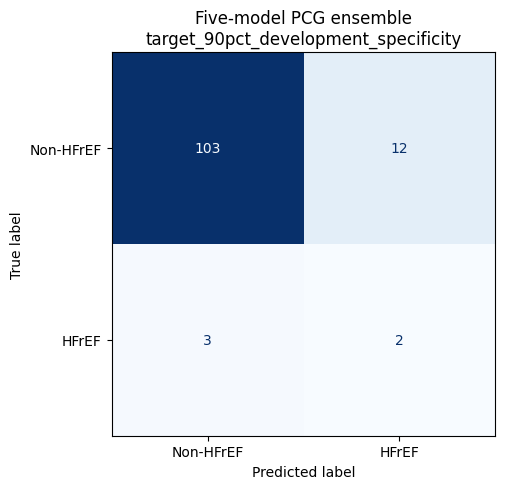


Original notebook 3.1 single model | original_saved_cutoff | cutoff 0.5028
              precision    recall  f1-score   support

   Non-HFrEF     1.0000    0.6261    0.7701       115
       HFrEF     0.1042    1.0000    0.1887         5

    accuracy                         0.6417       120
   macro avg     0.5521    0.8130    0.4794       120
weighted avg     0.9627    0.6417    0.7458       120



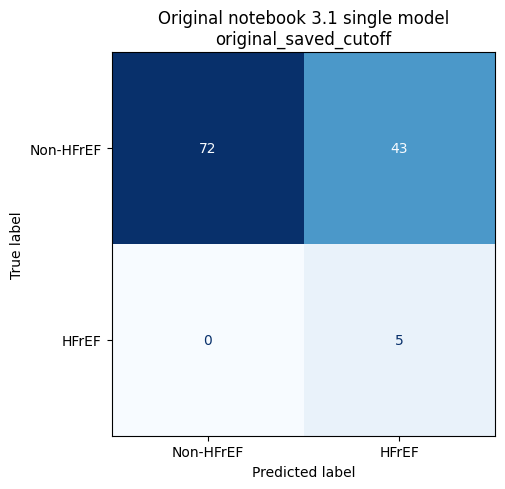

In [8]:
if test_results_path.is_file():
    for row in test_results.itertuples(index=False):
        tn, fp, fn, tp = (
            int(row.test_tn), int(row.test_fp),
            int(row.test_fn), int(row.test_tp),
        )
        true_labels = np.array([0] * (tn + fp) + [1] * (fn + tp))
        predictions = np.array([0] * tn + [1] * fp + [0] * fn + [1] * tp)
        matrix = np.array([[tn, fp], [fn, tp]])

        print(f"\n{row.model} | {row.cutoff_rule} | cutoff {row.development_cutoff:.4f}")
        print(classification_report(
            true_labels, predictions,
            labels=[0, 1],
            target_names=["Non-HFrEF", "HFrEF"],
            digits=4,
            zero_division=0,
        ))

        figure, axis = plt.subplots(figsize=(6, 5))
        ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=["Non-HFrEF", "HFrEF"],
        ).plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
        axis.set_title(f"{row.model}\n{row.cutoff_rule}")
        plt.tight_layout()
        plt.show()
else:
    print("Community test results have not been created.")

## How to read these results

Compare AUROC and AUPRC, then check how many HFrEF patients were found and how many false alarms occurred. A higher score at one cutoff alone does not establish a better model. The old models and new averages use different development-selected cutoffs.

Development scores use one held-out model per patient; test scores average five models. Their probability scales can differ. Also, each fold uses a different seed, so differences between folds reflect both the patients and training randomness.

Keeping the old baselines is a practical project decision. These results do not prove that five-fold evaluation or averaging models is generally worse. No model weights were updated using test data.

## Files made by this notebook

After training:

- Five `best_model.pt` files: one saved model for each validation fold.
- Five `history.csv` files: training loss, validation AUROC, and validation AUPRC by epoch.
- Five `validation_predictions.csv` files: the 100 held-out development predictions from each run.
- `development_oof_predictions.csv`: all 500 development predictions, one per patient.
- `development_summary.csv`: the combined development results and selected cutoffs.
- `fold_results.csv`: results shown separately for each fold.
- `run_settings.json`: settings and exact patient IDs used in every run.

After the separate community-test step:

- `community_test_fold_probabilities.csv`: each model's probability for each test patient.
- `community_test_ensemble_predictions.csv`: the averaged probability and decisions.
- `community_test_results.csv`: the ensemble and old-model comparison.

Large model files are ignored by Git. Result tables can be reviewed before deciding what belongs in a later commit.

## Observations and conclusion

- All five PCG folds finished. Validation AUROC ranged from 0.686 to 0.884. Both patient groups and training seeds changed between folds.
- Across 500 held-out development predictions, AUROC was 0.757 and AUPRC was 0.325. The main cutoff found 23 of 60 HFrEF patients and gave 38 false alarms among 440 non-HFrEF patients.
- On the community test set, the five-model average had AUROC 0.647 and AUPRC 0.269. The original model had AUROC 0.875 and AUPRC 0.162. The new result therefore improved AUPRC but reduced AUROC.
- The original model found all 5 HFrEF patients with 43 false alarms. The new main cutoff found 1 of 5 with 9 false alarms; its other development-selected cutoff found 2 of 5 with 12 false alarms.
- The new method reduced false alarms, but missed most HFrEF patients and had lower balanced accuracy. The old model also has a substantial false-alarm problem: 43 of 115 non-HFrEF patients were classified as HFrEF.

**Decision: keep the original notebook 3.1 PCG model as the baseline.** The new average does not offer a clear overall improvement. Preserve this run and its predictions as experiment records. Recover the original PCG checkpoint before using that model locally or in fusion; it is currently missing, so its comparison numbers come from saved notebook outputs.

### What remains uncertain

The new fold-0 model reached 0.777 validation AUROC, while the original run reached 0.669. The patient split and main settings match, but the exact loss operations and random training-crop sequence differ. We have not isolated their effects on PCG. The ECG loss finding cannot be assumed to apply to PCG.

Only five test patients have HFrEF, and the old checkpoint could not be evaluated again. These results do not establish that five-fold training is worse. If revisiting the experiment, first match the old loss and crop setup and investigate on development data.